In [1]:
import numpy as np
import pickle, os 
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath

In [2]:
projectPath, mainResultsPath = setProjectPath()

dataset_name = 'MDTB' # or Demand

# defining ROIs
large_ROI = 'PFC'
# large_ROI = 'visual'
# large_ROI = 'somatosensory'
# large_ROI = 'parietal'

resultsPath = os.path.join(mainResultsPath, 'START_B4_parcellation_sanity', dataset_name)
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

output = dict()
PKL_output = os.path.join(resultsPath, f'{dataset_name}_{large_ROI}_output.pkl')

In [3]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', dataset_name, f'output_{large_ROI}_masked.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    U_indiv = output_indiv['Uhat_data']
    U_indiv_label = np.argmax(U_indiv, axis=1) + 1
    U_group_label = output_indiv['U']
    V = output_indiv['V'].T             # n_parcels x n_conditions

In [4]:
n_subjects, n_parcels, P = U_indiv.shape

# count the number of parcels for each individual
n_parcels_per_indiv = [len(np.unique(x)) for x in U_indiv_label]

# count the number of vertices per parcel
n_vertices_per_parcel = np.zeros((n_subjects, n_parcels))
for subjI in np.arange(n_subjects):
    vals, counts = np.unique(U_indiv_label[subjI], return_counts=True)
    n_vertices_per_parcel[subjI] = counts

# load V compute similarity between each pair of parcels
V_simmats = np.corrcoef(V)

In [5]:
output['V'] = V
output['V_simmats'] = V_simmats
output['n_parcels_per_indiv'] = n_parcels_per_indiv
output['n_vertices_per_parcel'] = n_vertices_per_parcel

In [12]:
np.unique(V_simmats) 

array([-0.9321241 , -0.87017996, -0.8448687 , ...,  0.79861382,
        1.        ,  1.        ])

Text(0, 0.5, 'parcels')

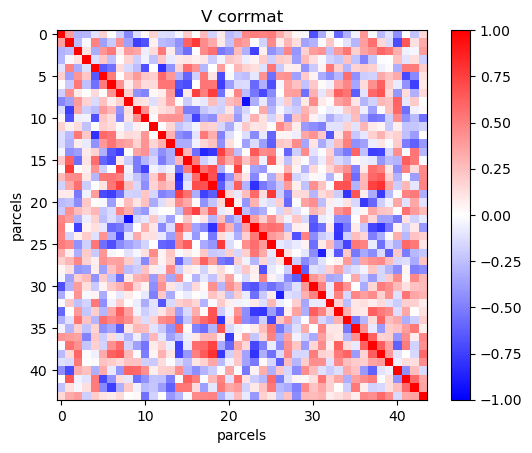

In [6]:
JPG_V_corrmat = os.path.join(resultsPath, f'V_corrmat.jpg')
fig, ax = plt.subplots(1, 1)
im = ax.imshow(V_simmats, cmap='bwr', vmin=-1, vmax=1)
ax.set_aspect('equal')
plt.colorbar(im)
ax.set_title(f'V corrmat')
ax.set_xlabel('parcels')
ax.set_ylabel('parcels')

In [7]:
plt.savefig(JPG_V_corrmat, dpi=400, format='jpg')

with open(PKL_output, 'wb') as pf:
    pickle.dump(output, pf)

<Figure size 640x480 with 0 Axes>

In [8]:
n_vertices_per_parcel 

array([[  82.,  217.,  376., ...,  633., 1586.,  311.],
       [  72.,  370.,  586., ...,  366.,  137.,   56.],
       [ 598.,  274.,  201., ...,  355.,  190.,   25.],
       ...,
       [ 157.,  591.,  155., ...,   98.,   20.,   56.],
       [ 226.,  203.,  172., ...,   44.,   13.,   31.],
       [ 477.,  220.,  744., ...,  212.,  352.,  249.]])